In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
%matplotlib inline

C:\Users\theha\AppData\Local\Temp\ipykernel_24792\1123203451.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
iris = datasets.load_iris()

In [3]:
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)

In [4]:
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
X = iris_data
y = pd.DataFrame(iris.target)

## Feature Scaling is must when we do K-means or Hierarchical Clustering.

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)

In [8]:
X_train_scaled = scaler.fit_transform(X_train)

In [9]:
X_test_scaled = scaler.transform(X_test)

## To visualize the cluster in 4D (with 4 features is not possible. s, we'll reduce the dimentisonality)

In [10]:
from sklearn.decomposition import PCA

In [11]:
pca = PCA(n_components=2)

In [12]:
pca_ = pca.fit_transform(X_train_scaled)

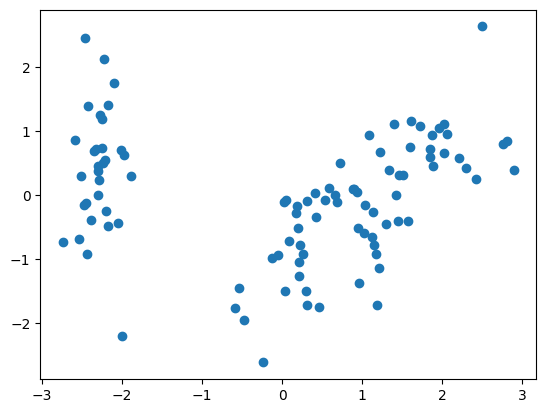

In [13]:
plt.scatter(pca_[:,0], pca_[:,1])

Text(0, 0.5, 'Eucledian Distance')

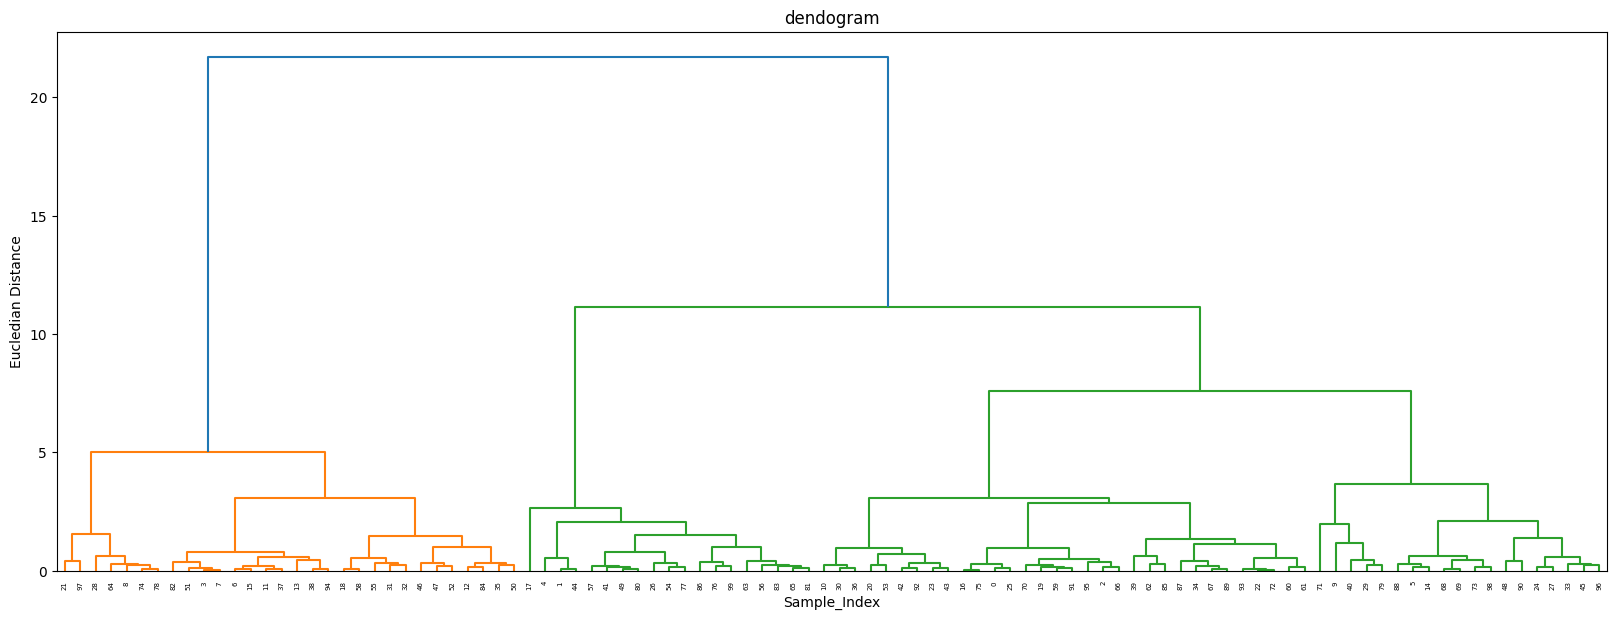

In [14]:
## Now,we'll import Agglomerative Clustering
## to Construct a dendogram

## THIS CODE IS TO BE REMEMBERED... ALWAYS USE THE SAME CODE... NO CHANGE !!
import scipy.cluster.hierarchy as sc
plt.figure(figsize=(20,7))
plt.title("Dendograms")

## create dendogram
sc.dendrogram(sc.linkage(pca_, method="ward"))
plt.title("dendogram")
plt.xlabel("Sample_Index")
plt.ylabel("Eucledian Distance")

In [15]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2, metric="euclidean", linkage="ward")
cluster.fit(pca_)

AgglomerativeClustering()

In [16]:
cluster.labels_

array([0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0], dtype=int64)

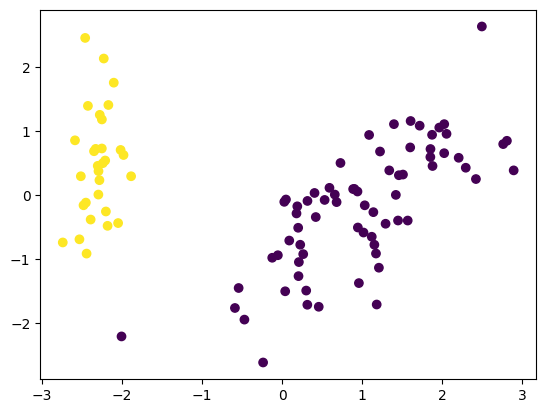

In [17]:
plt.scatter(pca_[:,0], pca_[:,1], c=cluster.labels_)

In [24]:
from sklearn.metrics import silhouette_score
silhoutte_coefficients = []
for k in range(2,11):
    agglo = AgglomerativeClustering(n_clusters=k, metric="euclidean", linkage="ward")
    agglo.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled, agglo.labels_)
    silhoutte_coefficients.append(score)

In [25]:
silhoutte_coefficients

[0.5604478086733395,
 0.4715766410756801,
 0.4284080783505499,
 0.37457195131543486,
 0.36971385271677343,
 0.34850263243961277,
 0.3379142824872986,
 0.3173213285980799,
 0.32004020748495]

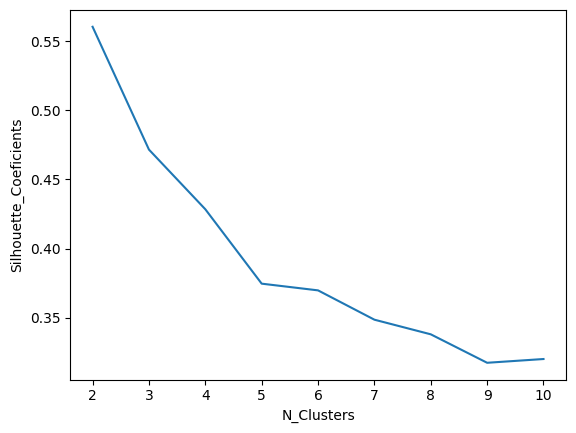

In [27]:
plt.plot(range(2,11), silhoutte_coefficients)
plt.xticks(range(2,11))
plt.xlabel("N_Clusters")
plt.ylabel("Silhouette_Coeficients")
plt.show()